<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/7.0%20Final_Delivery%3A%20Churn%20and%20CLTV%20Inference%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
#!pip install s3fs

### 1.0 INTRODUCTION
Having trained and validated `Segmentation`, `Churn`, and `CLTV` predictive models on data before `2011-08-31`, this notebook serves as the inference backend, making prediction on customer data without known outcomes, currently data after `2011-08-31`.

#### 1.1 Extract, Load and Transform (ETL) Pipeline
- The `data engineering notebook` receives unclean data as it would would be captured during data entry, stored in AWS S3 datalake as an excel file, loads it into a dataframe, upon which a data cleaning function created in the `data engineering` notebook is applied, and once cleaned, uploaded as a parquet file back to AWS datalake.

#### 1.2 Inference Pipeline
- The clean data from AWS, as a parquet file, is imported and loaded into a dataframe in this notebook, the feature engineering function is applied to clients that currently have a 60-day tenure.
- The joblib files holding the segmentation, churn, and cltv predictive models, are streamed and loaded into memory. Thereafter, each customers churn status and probability in the next 100 days is predicted; moreover, their expected 100-day spend, `if they don't churn`, is also predicted. Once all prediction have been made, they are loaded into an SQL table to serve as a centralised location for business intelligence access.

Preview of data streamed from AWS S3 before feature engineering:

In [46]:
import sys
import os
import importlib
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

from datetime import datetime

bucket_name = 'sales-data-analytics-portfolio-2026'

os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail_clean.parquet"

cutoff_date = '2011-09-01'

df = pd.read_parquet(parquet_url)


#df = df[df["InvoiceDate"].dt.date.astype('str') > cutoff_date].reset_index(drop = True)
df.info()
print("\nPreview of data exported from AWS S3 datalake")
print()
df.sort_values("InvoiceDate").head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396370 entries, 0 to 396369
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    396370 non-null  object        
 1   StockCode    396370 non-null  object        
 2   Description  396370 non-null  object        
 3   Quantity     396370 non-null  int64         
 4   InvoiceDate  396370 non-null  datetime64[ns]
 5   UnitPrice    396370 non-null  float64       
 6   CustomerID   396370 non-null  float64       
 7   Country      396370 non-null  object        
 8   Revenue      396370 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 27.2+ MB

Preview of data exported from AWS S3 datalake



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### 2.0 FEATURE ENGINEERING

This section extracts features from raw transactions, for the first 60-days of every client's spend after `2011-08-31`, filtered for those hit the predefined tenure mark by `2011-12-09`.

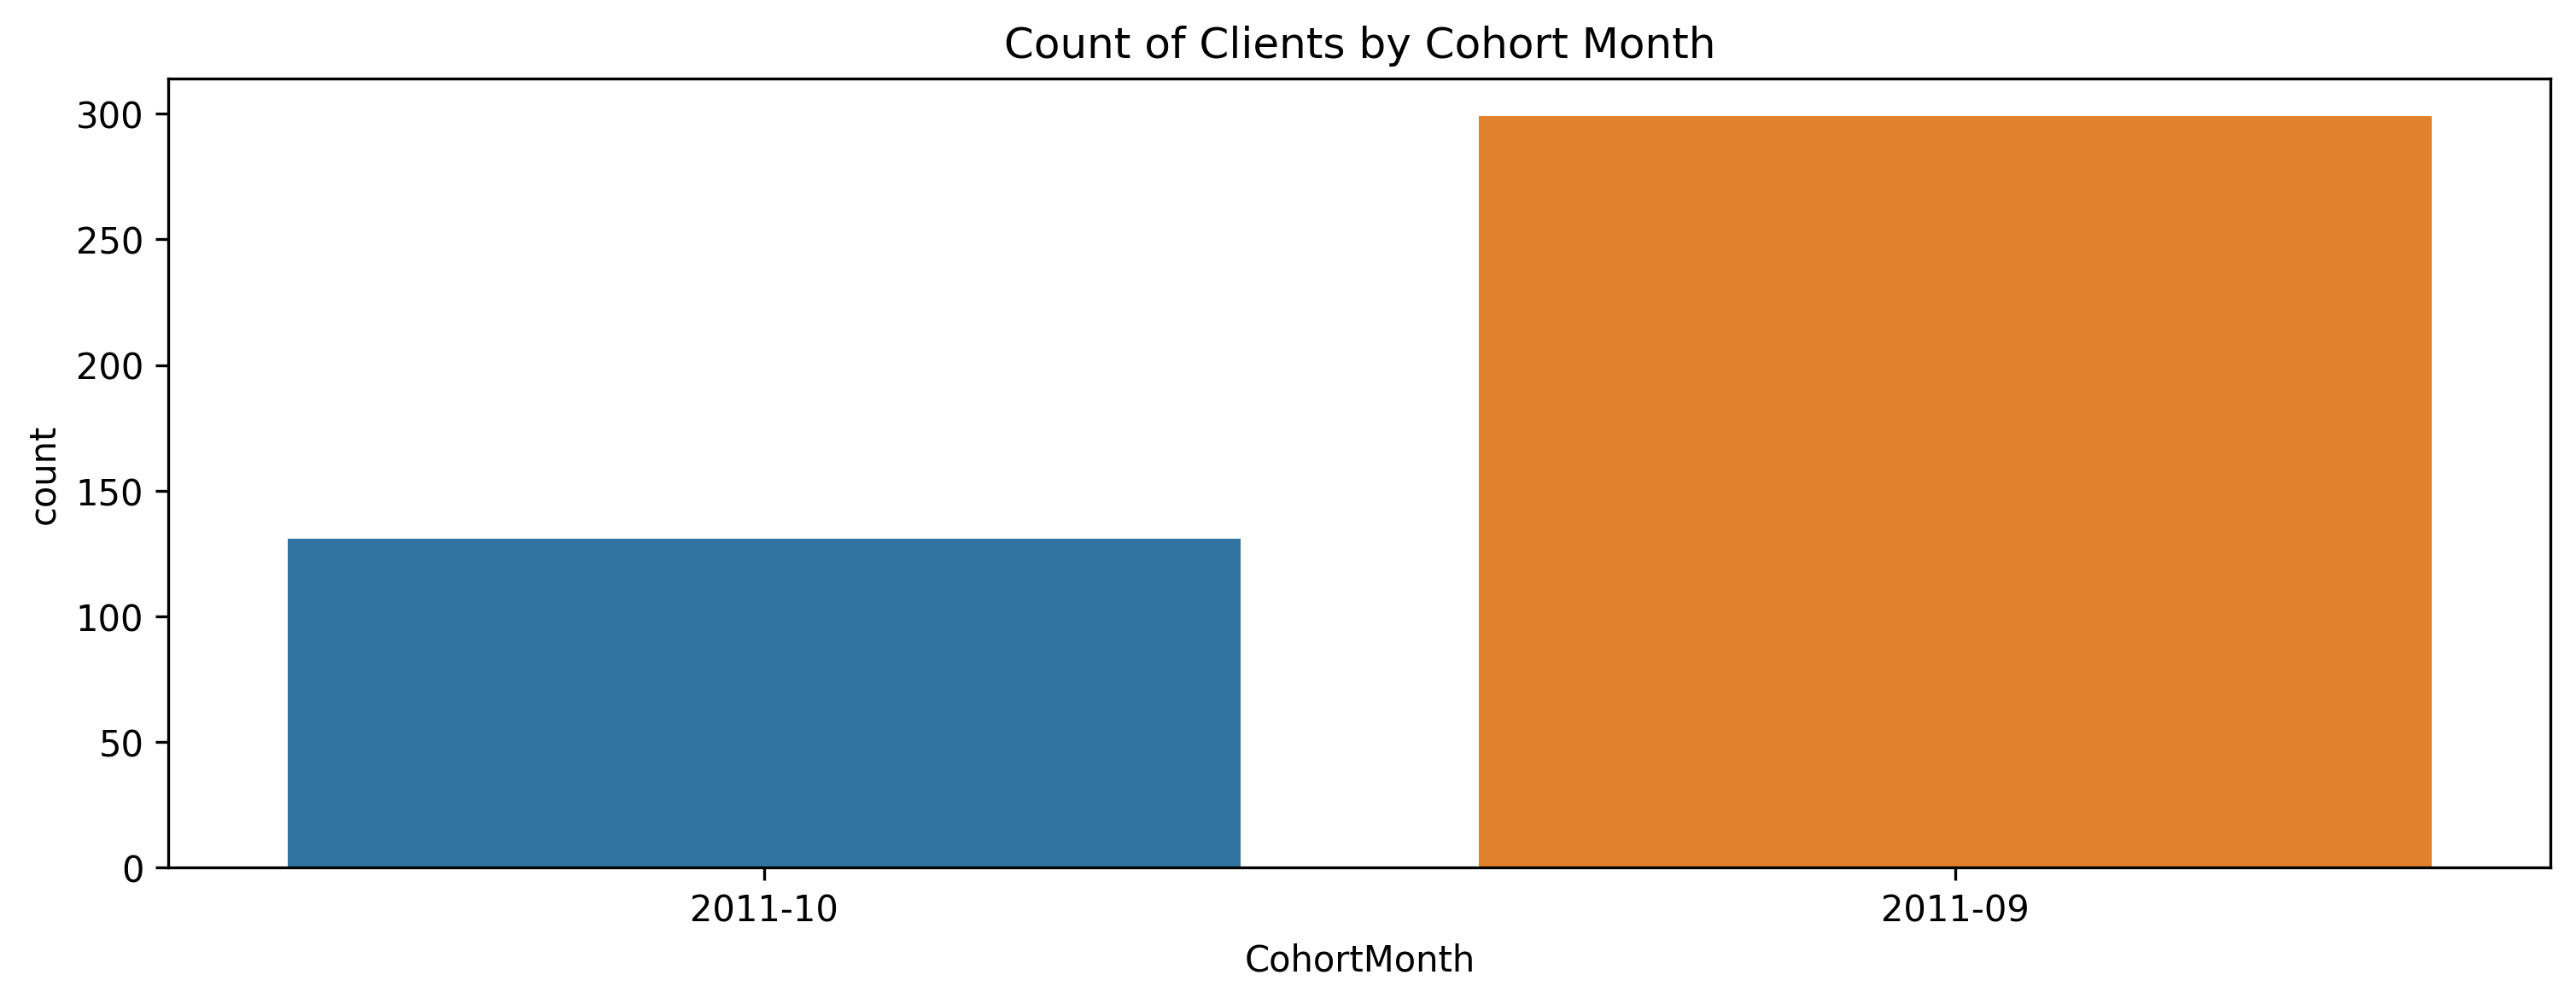

Preview of features extracted by feature_engineering function, from which each model's features are selected

<class 'pandas.core.frame.DataFrame'>
Index: 430 entries, 3 to 1020
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   CustomerID               430 non-null    float64  
 1   Frequency                430 non-null    int64    
 2   ProductDiversity         430 non-null    int64    
 3   AvgUnitPrice             430 non-null    float64  
 4   AvgQuantity              430 non-null    float64  
 5   AOV                      430 non-null    float64  
 6   TotalRevenue             430 non-null    float64  
 7   CohortMonth              430 non-null    period[M]
 8   Recency                  430 non-null    int64    
 9   Tenure                   430 non-null    int64    
 10  ObservedLifeSpan         430 non-null    int64    
 11  RecencyToTenure          430 non-null    float64  
 12  

,CustomerID,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,TotalRevenue,CohortMonth,Recency,Tenure,ObservedLifeSpan,RecencyToTenure,ActivePurchaseDensity,LifetimePurchaseDensity,ActiveMRate,LifetimeMRate,AvgIPI,RelativeSilence
3,12371.0,1,62,3.291613,9.387097,24.644516,1527.96,2011-10,60,60,1,1.0,1.0,0.016667,1527.96,25.466000,1.0,60.0
5,12375.0,1,10,2.712000,8.600000,19.030000,190.30,2011-09,98,98,1,1.0,1.0,0.010204,190.30,1.941837,1.0,98.0
6,12390.0,1,31,3.641935,11.290323,16.285161,504.84,2011-09,80,80,1,1.0,1.0,0.012500,504.84,6.310500,1.0,80.0
10,12420.0,1,29,4.707241,11.896552,20.703103,600.39,2011-10,64,64,1,1.0,1.0,0.015625,600.39,9.381094,1.0,64.0
11,12425.0,1,36,2.564444,13.777778,21.588889,777.20,2011-09,78,78,1,1.0,1.0,0.012821,777.20,9.964103,1.0,78.0


In [47]:
import s3fs

fs = s3fs.S3FileSystem()
function_url = "s3://sales-data-analytics-portfolio-2026/functions/feature_engineering.py"

with fs.open(function_url, "r") as file:
    exec(file.read())


from datetime import timedelta
data = df.groupby("CustomerID").agg(
FirstPurchase = ("InvoiceDate", "min")
).reset_index()

cutoff_days = timedelta(days = 60)

data["Cutoff"] = data["FirstPurchase"] + cutoff_days

df = df.merge(data, on = "CustomerID", how = "left")

X_features = df[df["InvoiceDate"] <= df["Cutoff"]].copy()
X_features = X_features[X_features["FirstPurchase"].astype("str") >= cutoff_date]

X_features.drop(["FirstPurchase", "Cutoff"], axis = 1, inplace = True)

X_features = feature_engineering(X_features)

#Filtering Segmentation to Ensure Each client had the chance to shop with in exactly 60 from first purchase
X_features = X_features[X_features['Tenure'] >= 60]

features = X_features.fillna(0)

df1 = features

plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = df1, x = "CohortMonth", hue = "CohortMonth")
plt.title("Count of Clients by Cohort Month")
plt.show()

print("Preview of features extracted by feature_engineering function, from which each model's features are selected")
print()
df1.info()
print()
df1.head()

### 3.0 Customer Segment Assignment, and Churn and CLTV predictions
In this section, the KMeans Clustering, Churn, and CLTV trained models are import from AWS S3, and prediction are made.

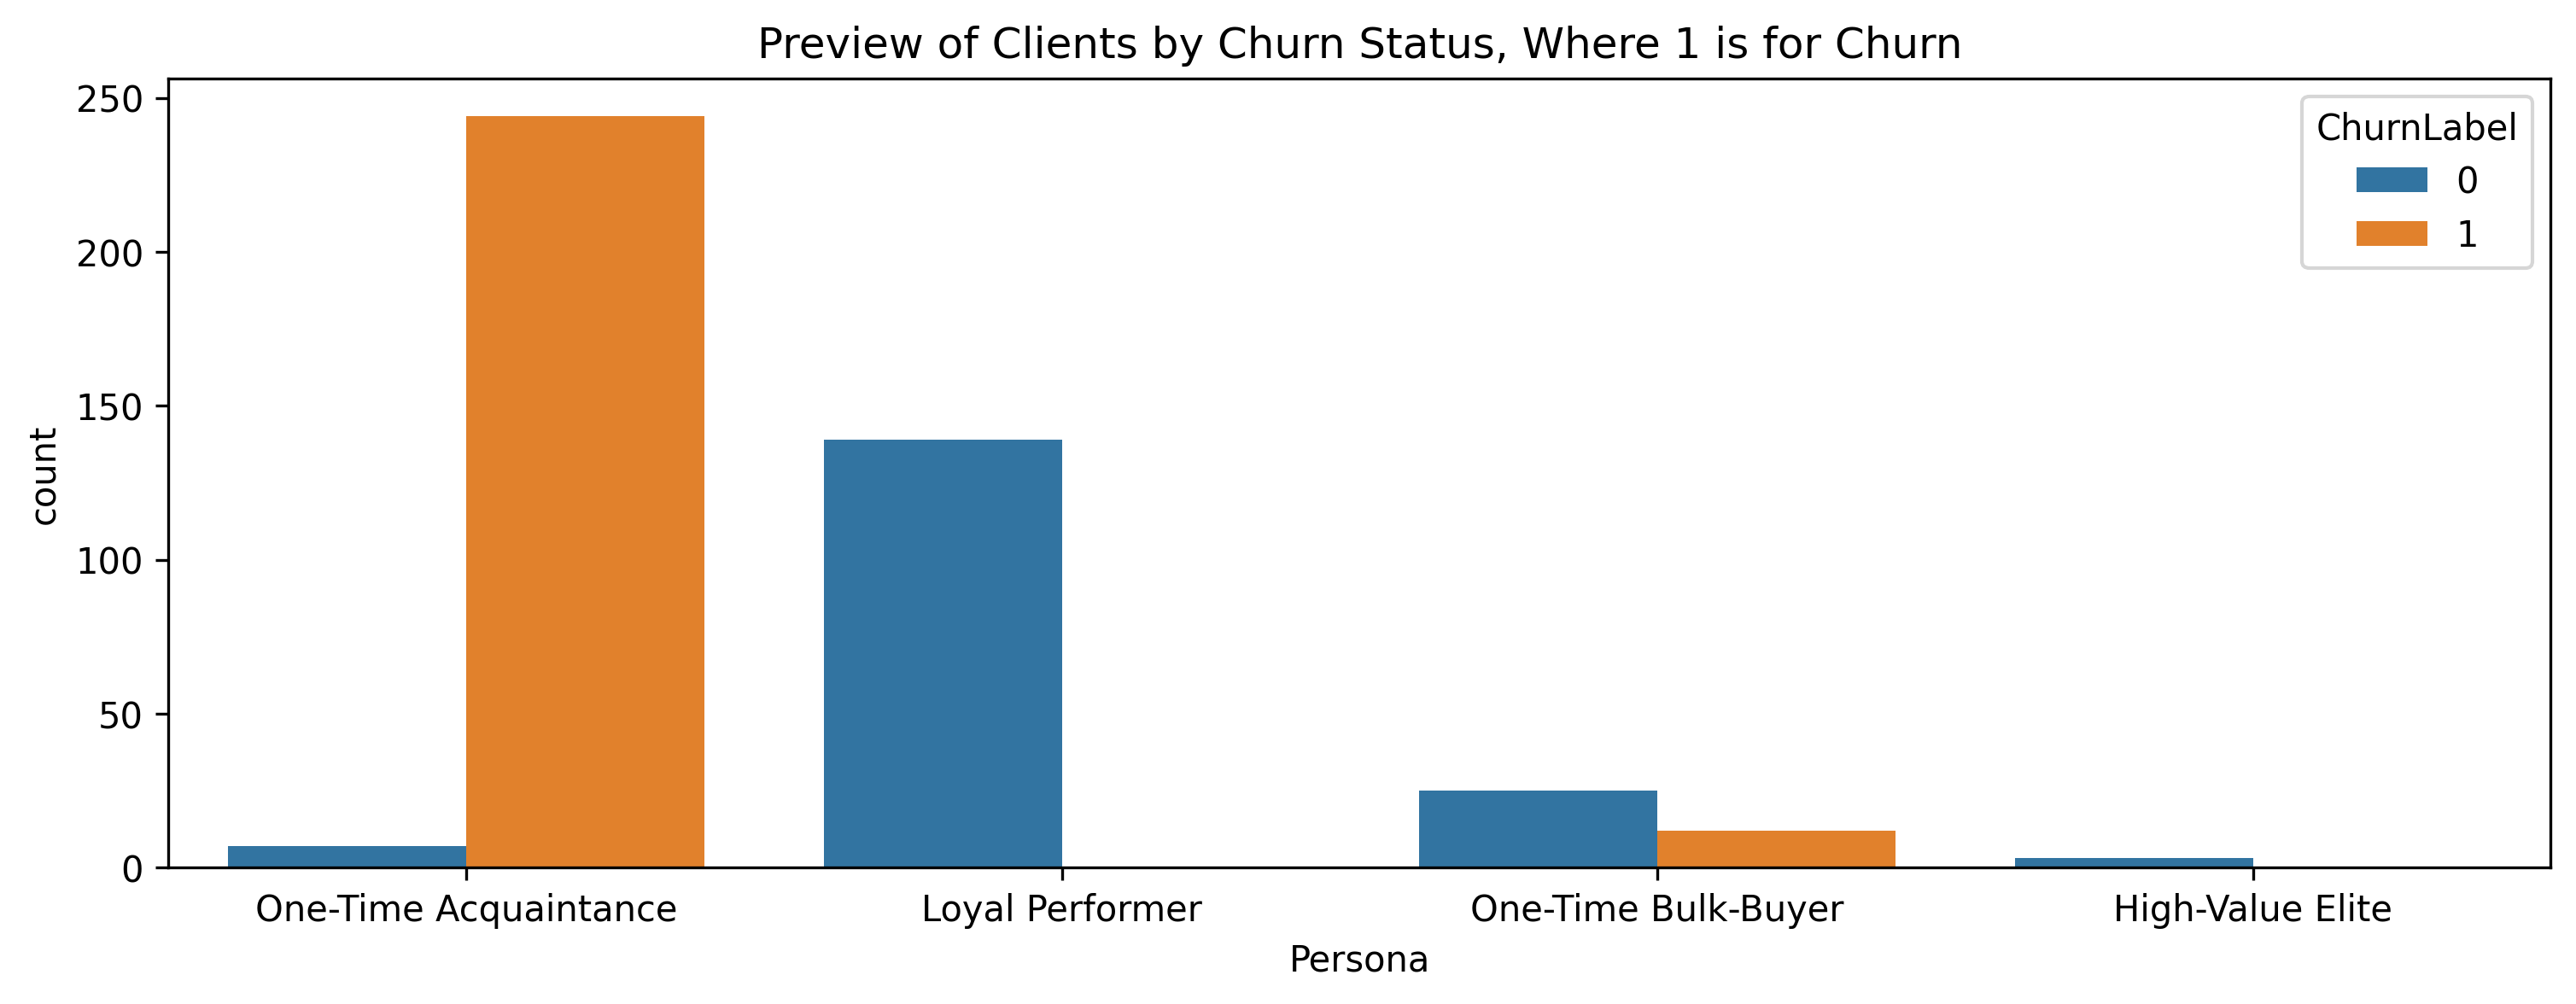

Preview of Model Predictions:



,CustomerID,Persona,ChurnProbability,ChurnLabel,PredictedCLTV
3,12371.0,One-Time Acquaintance,0.595569,1,970.629566
5,12375.0,One-Time Acquaintance,0.722733,1,321.938432
6,12390.0,One-Time Acquaintance,0.696702,1,442.386697
10,12420.0,One-Time Acquaintance,0.698858,1,535.271182
11,12425.0,One-Time Acquaintance,0.658181,1,775.365605


In [53]:
# loading models into memory from data

kmeans = "s3://sales-data-analytics-portfolio-2026/predictive_models/kmeans_segmentation_60.joblib"
churn = "s3://sales-data-analytics-portfolio-2026/predictive_models/churn_model.joblib"
cltv = "s3://sales-data-analytics-portfolio-2026/predictive_models/cltv_model.joblib"

with fs.open(kmeans, "rb") as f:
    loaded_kmeans_model = joblib.load(f)

with fs.open(churn, "rb") as f:
    loaded_churn_model = joblib.load(f)

with fs.open(cltv, "rb") as f:
    loaded_cltv_model = joblib.load(f)

# Features to drop from features dataframe by model
segmentation_features = ["CustomerID", "CohortMonth", "Recency", "Tenure", "RecencyToTenure", "LifetimePurchaseDensity","LifetimeMRate","RelativeSilence"]
churn_features = ["TotalRevenue","Churned", "KSegment","CustomerID", "CohortMonth", "Recency", "Tenure", "RecencyToTenure", "LifetimePurchaseDensity","LifetimeMRate","RelativeSilence"]
cltv_features = ['ActiveMRate','TotalRevenue','RevenueTarget','KSegment','AOVTarget','FrequencyTarget', 'RevenueTarget', 'CustomerID', 'CohortMonth', 'Tenure', 'Recency', 'RecencyToTenure', 'LifetimePurchaseDensity', 'LifetimeMRate', 'RelativeSilence']

# Assigning Kmeans labels
kmeans_labels = loaded_kmeans_model.predict(df1[loaded_kmeans_model.feature_names_in_])

df2 = df1.copy()
df2["KSegment"] = kmeans_labels

persona_map = {
    2: "One-Time Acquaintance",
    1: "Loyal Performer",
    3: "High-Value Elite",
    0: "One-Time Bulk-Buyer"
}

df2["Persona"] = df2["KSegment"].map(persona_map)

# Predicting churn label and probabilities
X_churn = pd.get_dummies(df2, drop_first = True)
X_churn = X_churn[loaded_churn_model.feature_names_in_]


churn_label = loaded_churn_model.predict(X_churn)
churn_proba = loaded_churn_model.predict_proba(X_churn)[:,1]

df3 = df2.copy()
df3["ChurnLabel"] = churn_label
df3["ChurnProbability"] = churn_proba

# Predicting 100-days customer lifetime value
X_cltv = pd.get_dummies(df2, drop_first = True)
X_cltv = X_churn[loaded_cltv_model.feature_names_in_]

cltv_100 = loaded_cltv_model.predict(X_cltv)
df3["PredictedCLTV"] = cltv_100

# Filtering dataframe for customers expected to churn
churned_df = df3.query('ChurnLabel == 1').copy()

plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = df3, x = "Persona", hue = "ChurnLabel")
plt.title("Preview of Clients by Churn Status, Where 1 is for Churn")
plt.show()

print("Preview of Model Predictions:")
print("")
churned_df[["CustomerID", "Persona", "ChurnProbability", "ChurnLabel", "PredictedCLTV"]].head()

#### 3.1 Analyzing 60-day Customer Segments by Key Metrics

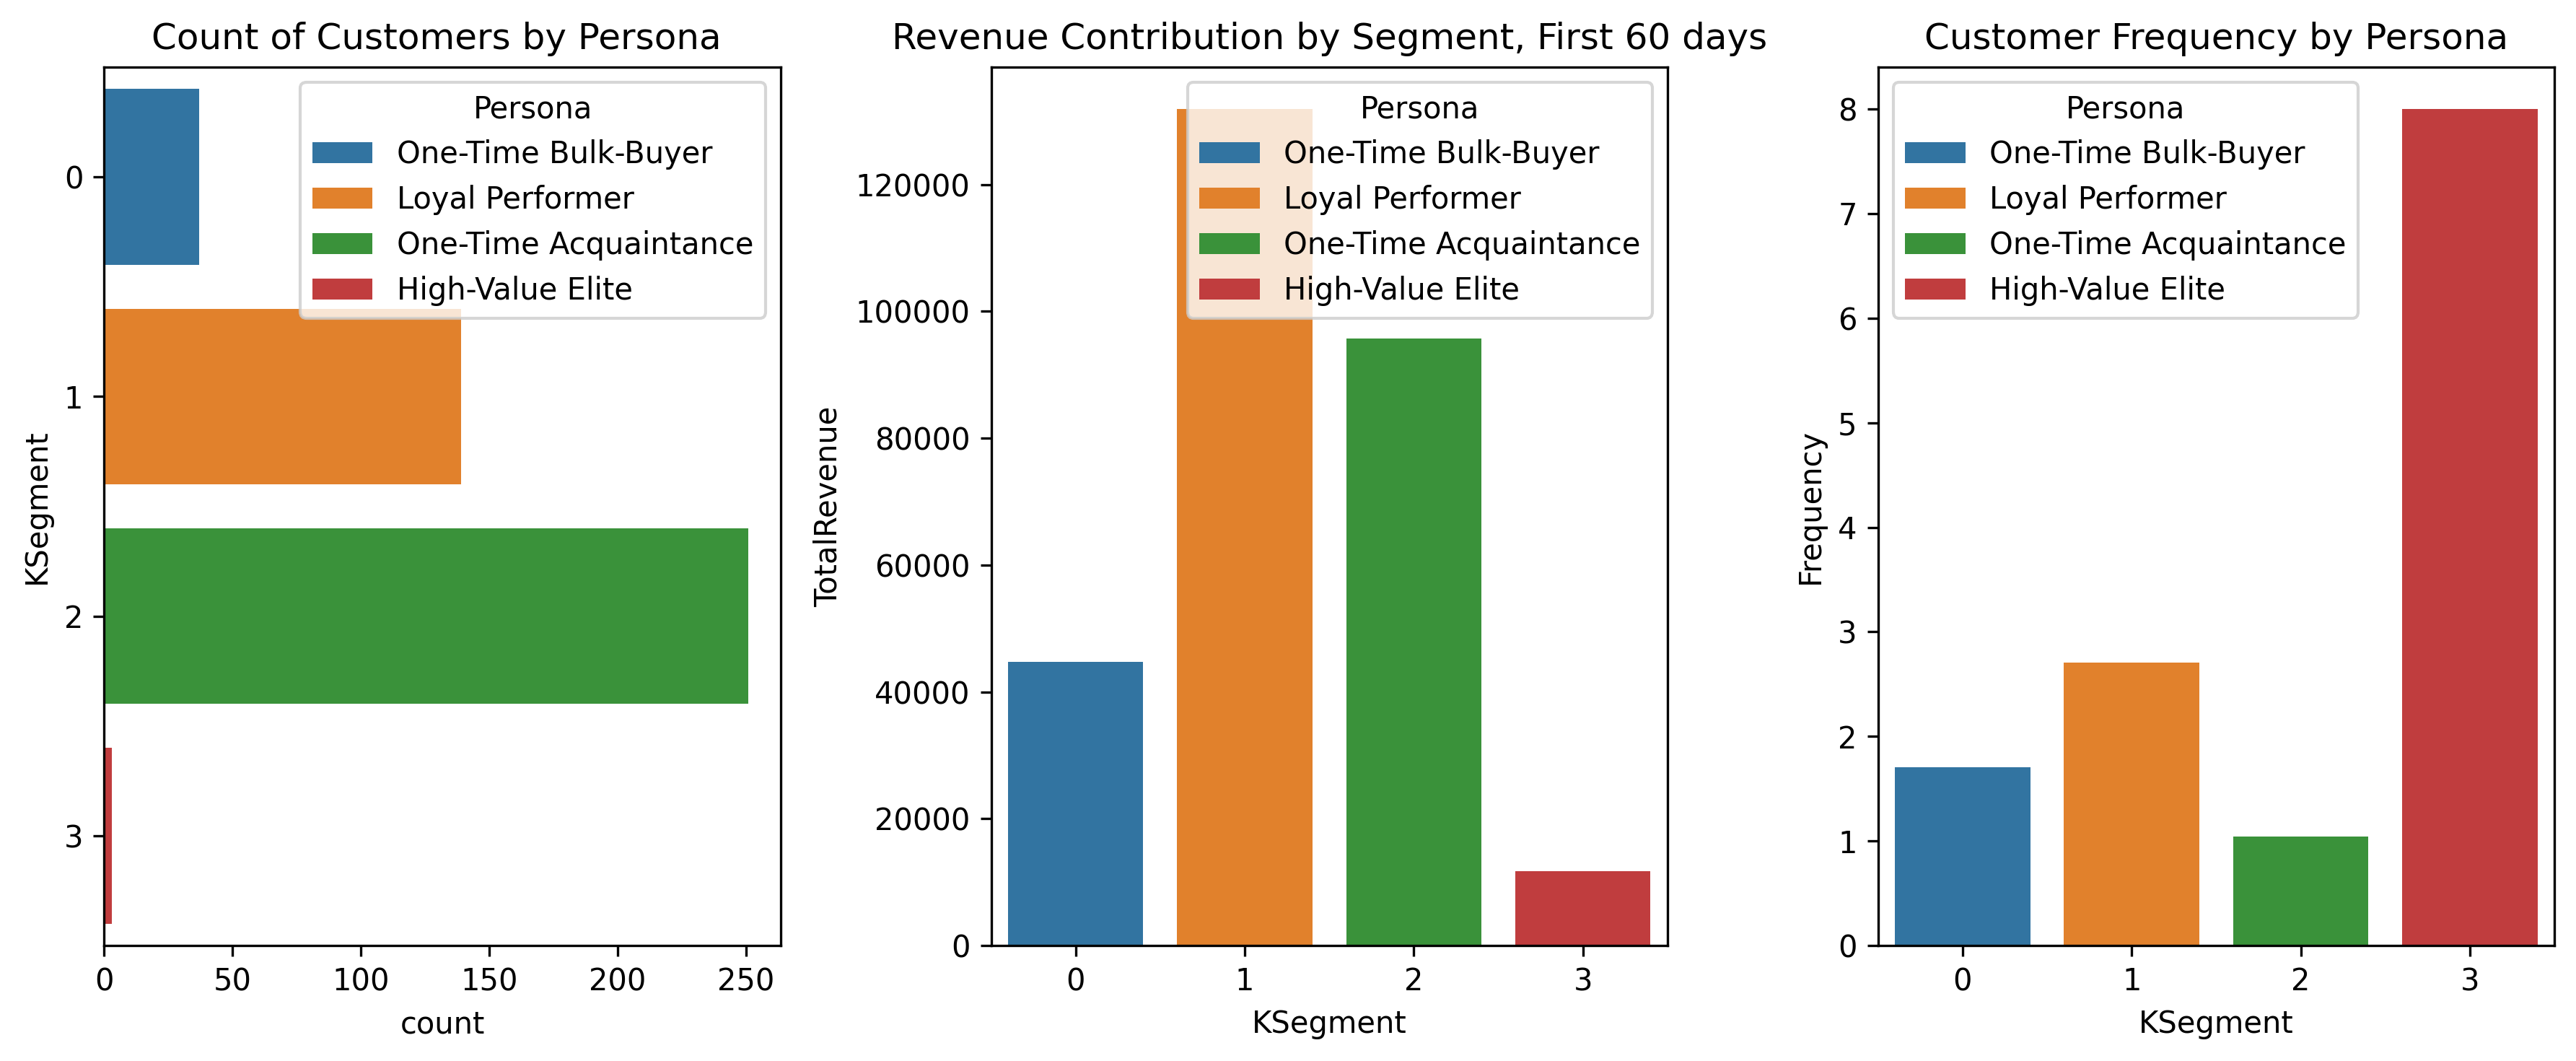

In [49]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (12,5), dpi = 300)
sns.barplot(data = df3, x = "KSegment", y = "Frequency", errorbar = None, hue = "Persona", ax = ax3)
ax3.set_title("Customer Frequency by Persona")

sns.barplot(data = df3, x = "KSegment", y = "TotalRevenue", estimator = 'sum', errorbar = None, hue = "Persona", ax = ax2)
ax2.set_title("Revenue Contribution by Segment, First 60 days")

sns.countplot(data = df3, y = "KSegment", hue = "Persona", ax = ax1)
ax1.set_title("Count of Customers by Persona ")
#plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

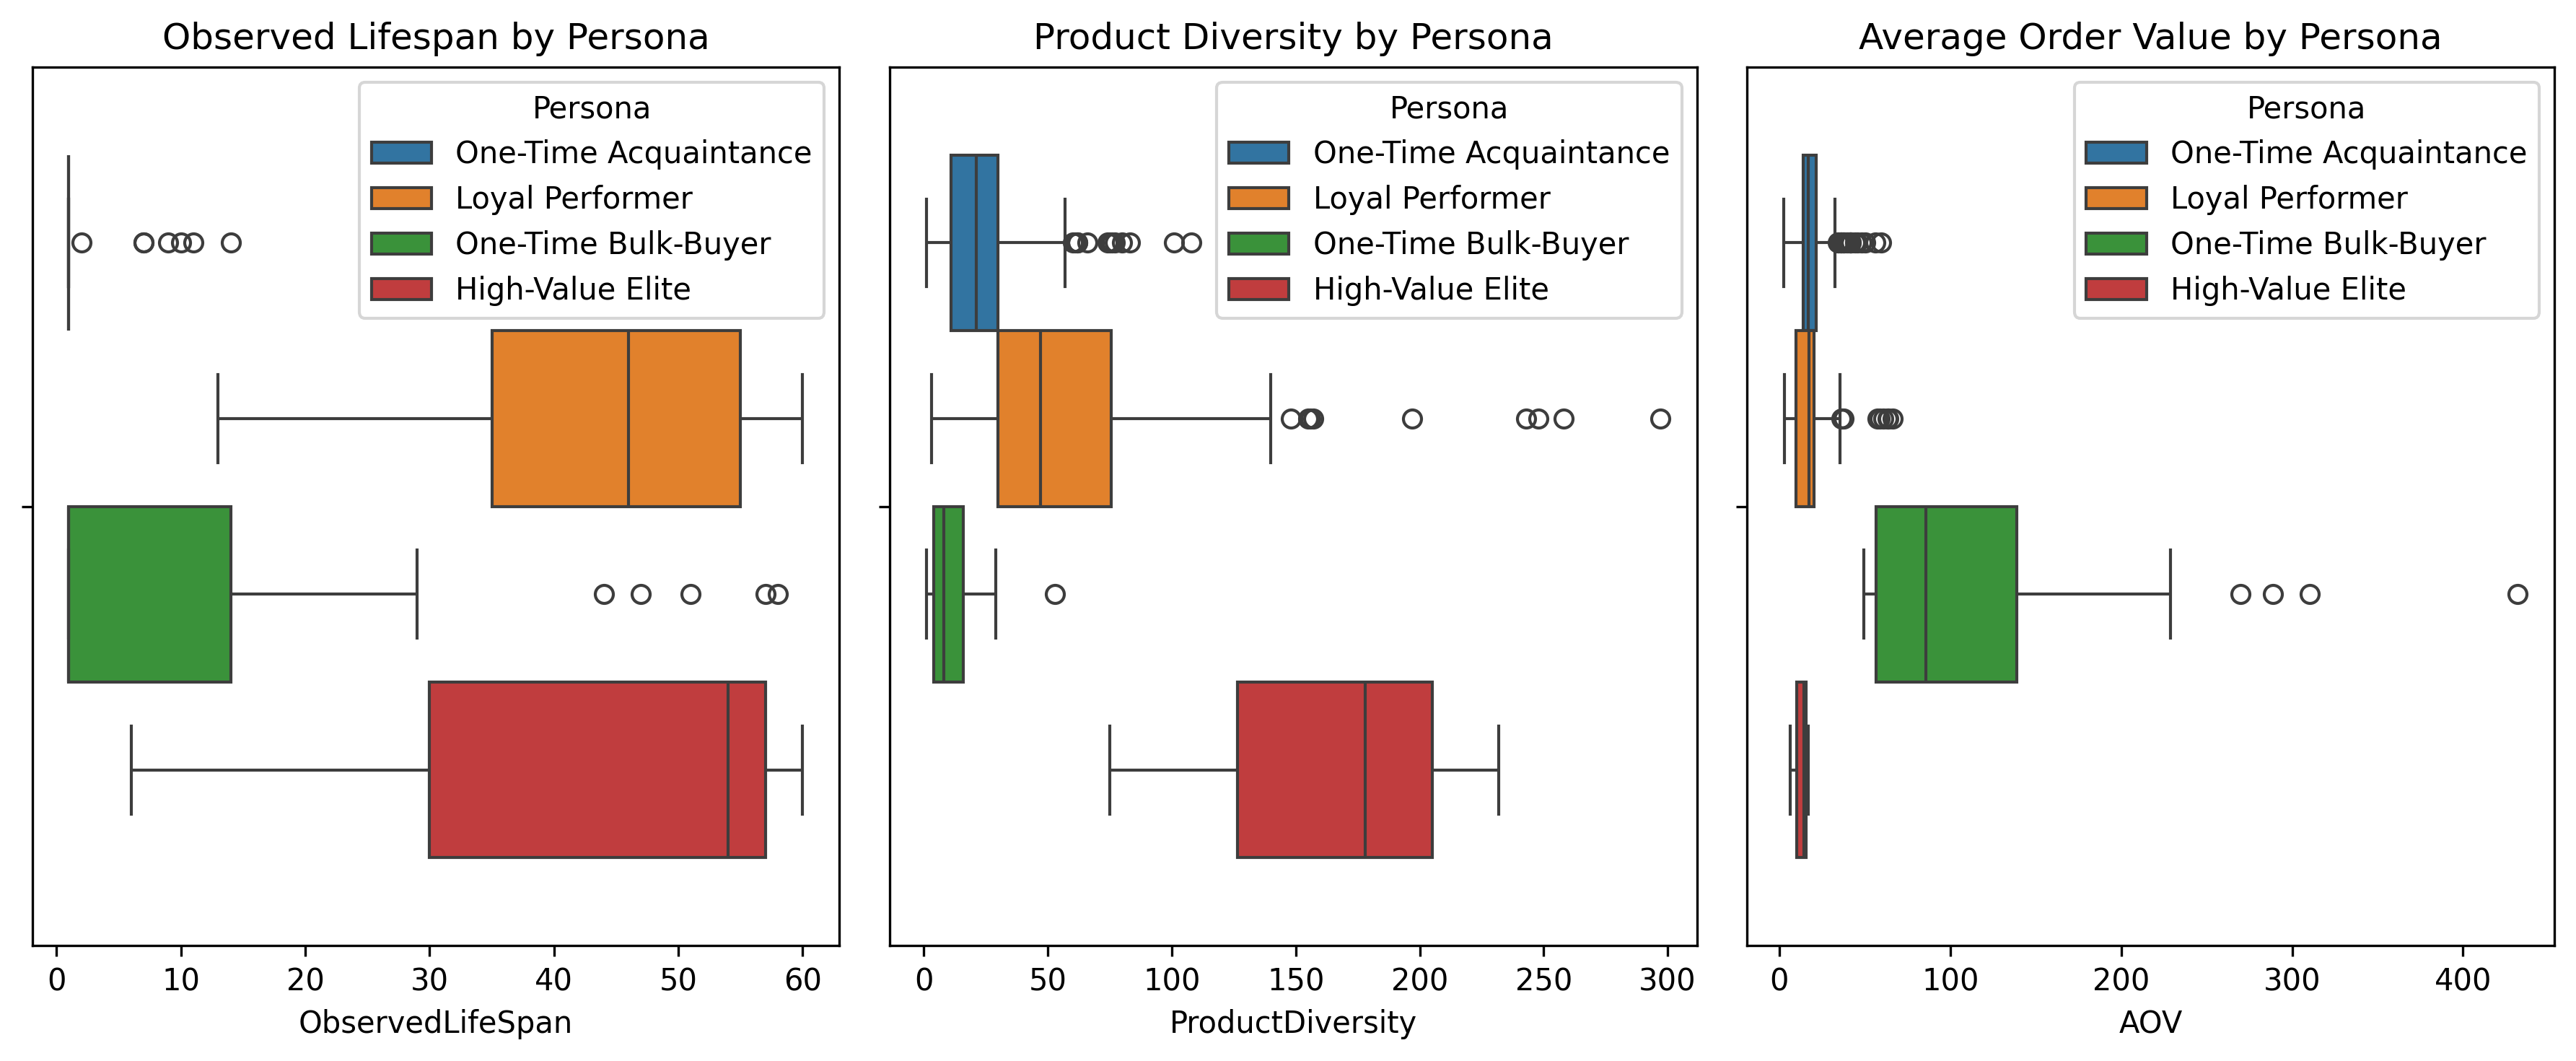

In [50]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (12,5), dpi = 300)
sns.boxplot(data = df3, x = "AOV", hue = "Persona", ax = ax3)
ax3.set_title("Average Order Value by Persona")

sns.boxplot(data = df3, x = "ProductDiversity", hue = "Persona", ax = ax2)
ax2.set_title("Product Diversity by Persona")

sns.boxplot(data = df3, x = "ObservedLifeSpan", hue = "Persona", ax = ax1)
ax1.set_title("Observed Lifespan by Persona")
#plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

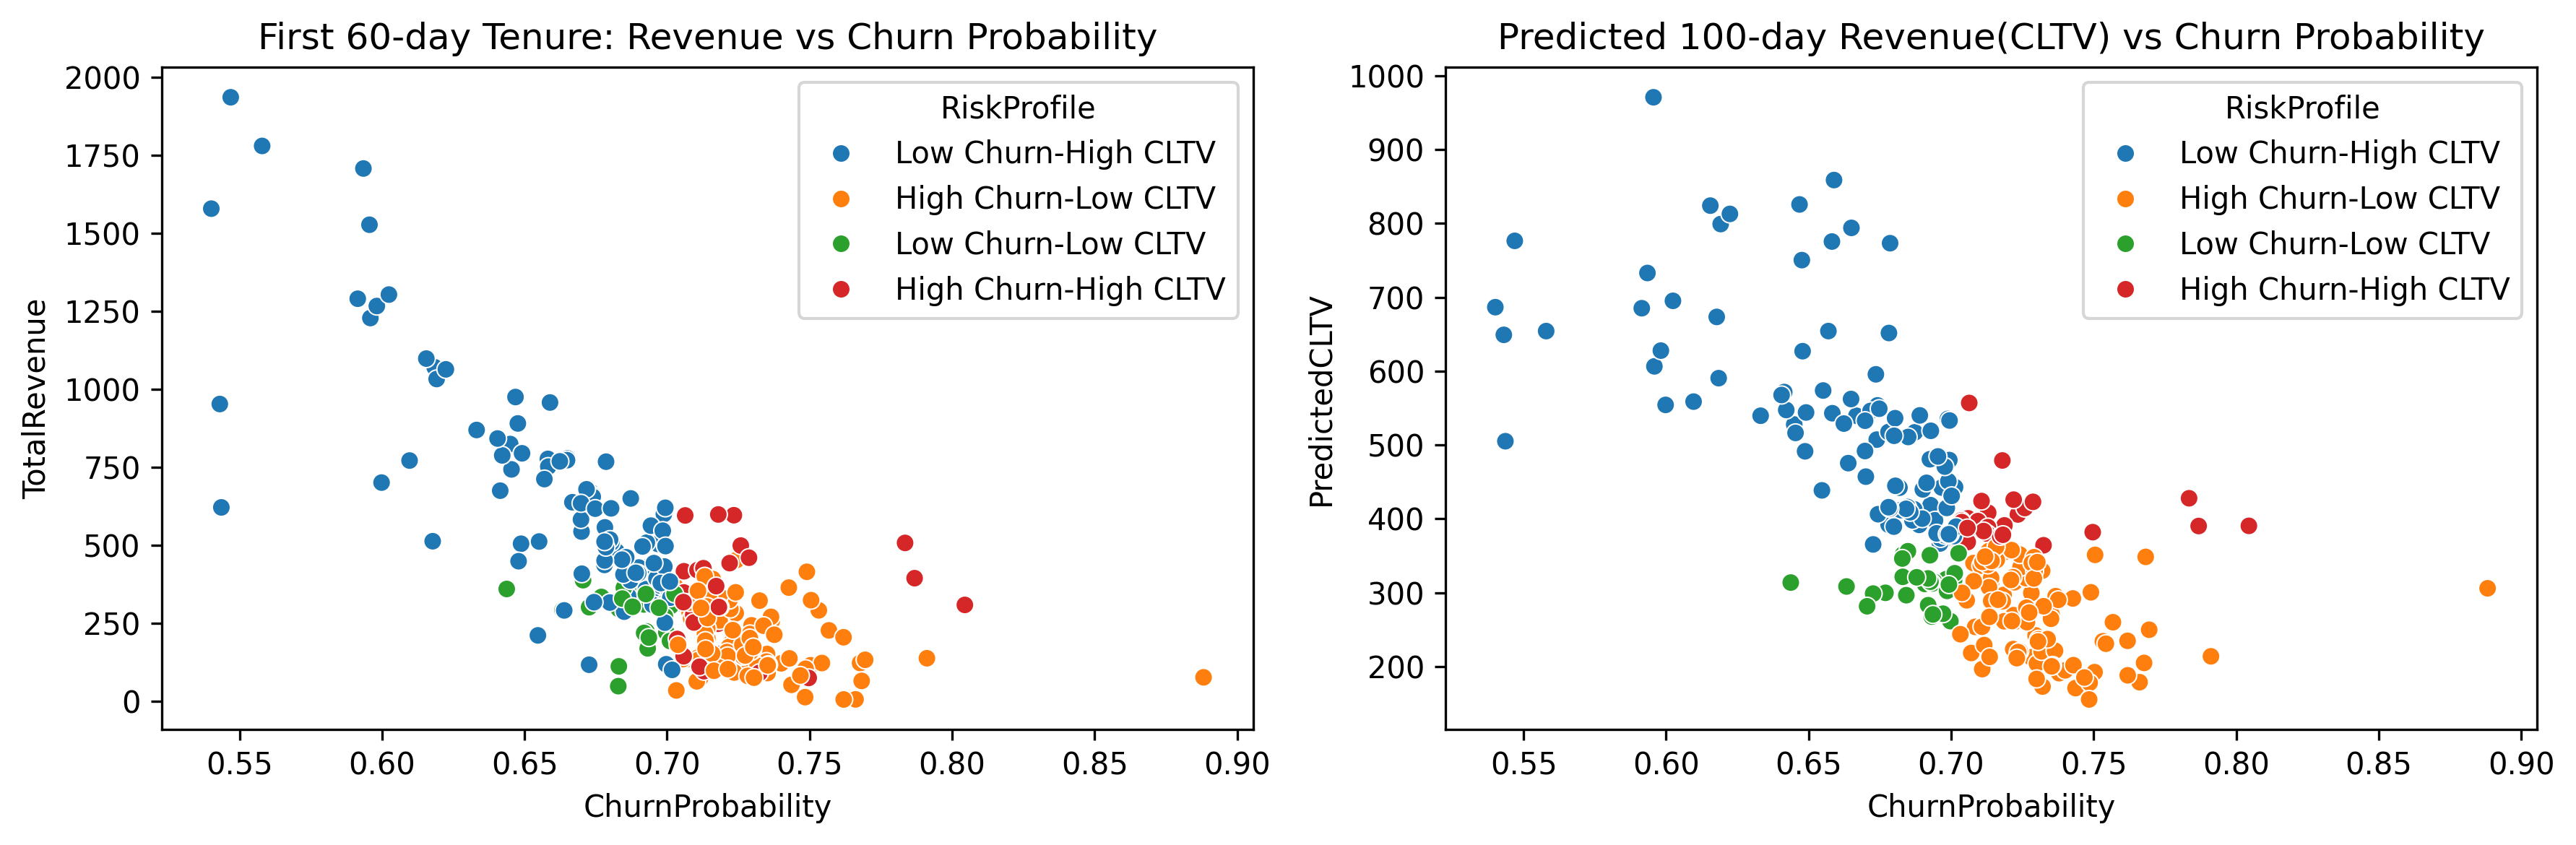

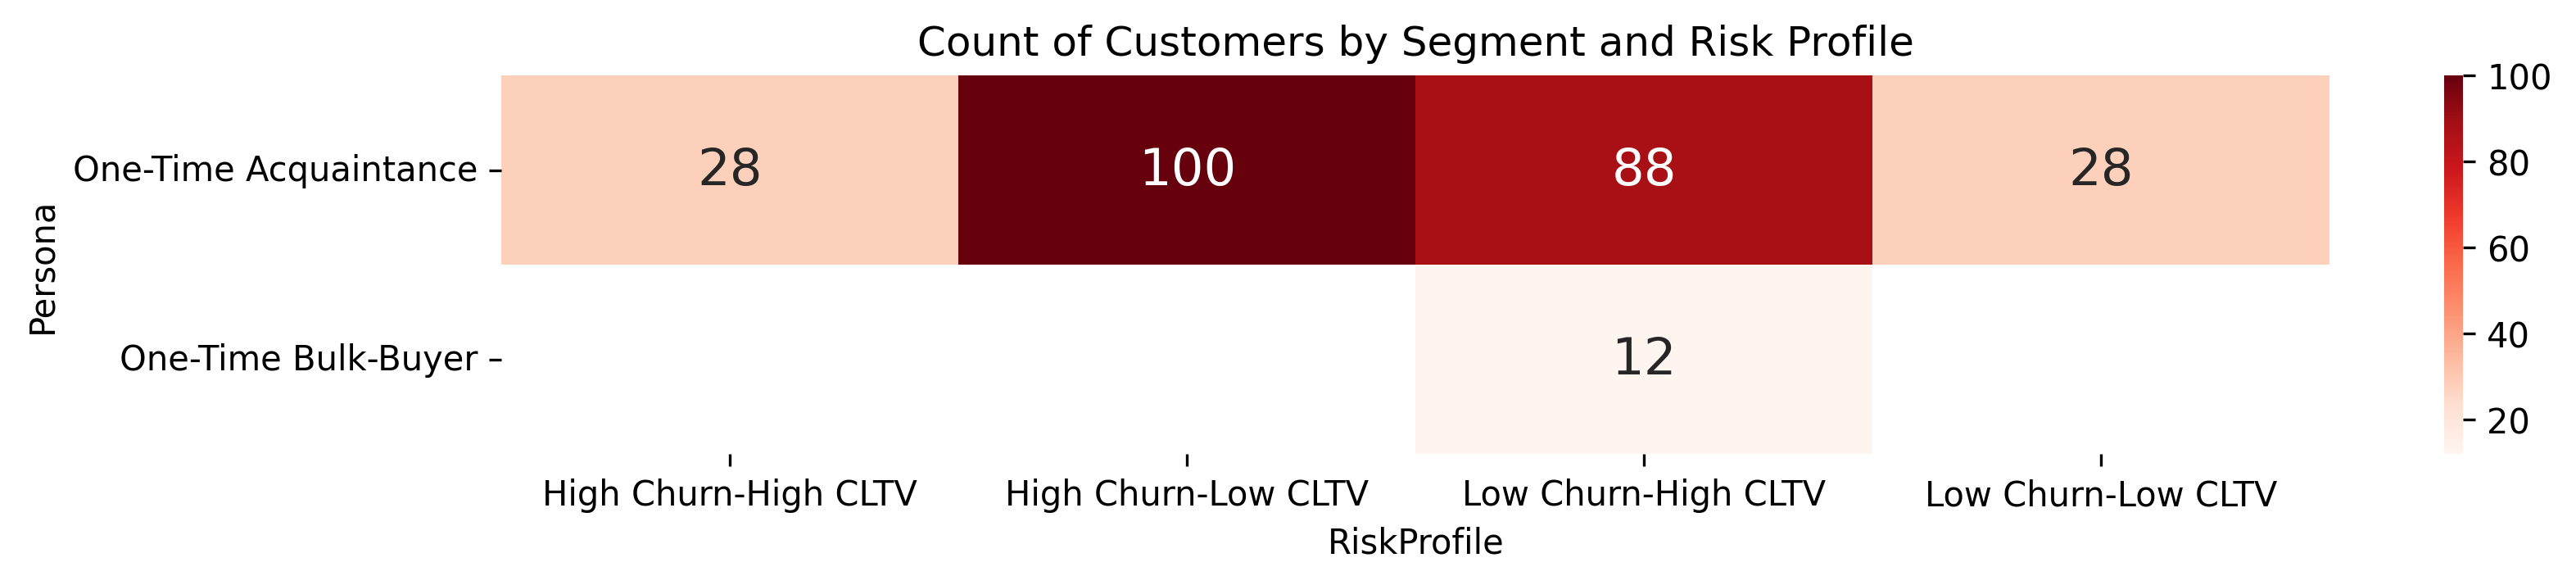

In [51]:
churned_df["ChurnClass"] = pd.qcut(churned_df["ChurnProbability"], q = 2, labels = ["Low Churn", "High Churn"])
churned_df["CLTVClass"] = pd.qcut(churned_df["PredictedCLTV"], q = 2, labels = ["Low CLTV", "High CLTV"])
churned_df["RiskProfile"] = churned_df["ChurnClass"].astype("str") + '-' + churned_df["CLTVClass"].astype("str")
df3["RiskProfile"] = churned_df["ChurnClass"].astype("str") + '-' + churned_df["CLTVClass"].astype("str")

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4), dpi = 300)
sns.scatterplot(data = df3, x = 'ChurnProbability', y = 'TotalRevenue', hue = 'RiskProfile', ax = ax1)
ax1.set_title('First 60-day Tenure: Revenue vs Churn Probability')

sns.scatterplot(data = df3, x = 'ChurnProbability', y = 'PredictedCLTV', hue = 'RiskProfile', ax = ax2)
ax2.set_title('Predicted 100-day Revenue(CLTV) vs Churn Probability')
plt.tight_layout()
plt.show()

summary = churned_df.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'CustomerID', aggfunc = 'count')

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Reds')
plt.title('Count of Customers by Segment and Risk Profile')
plt.show()



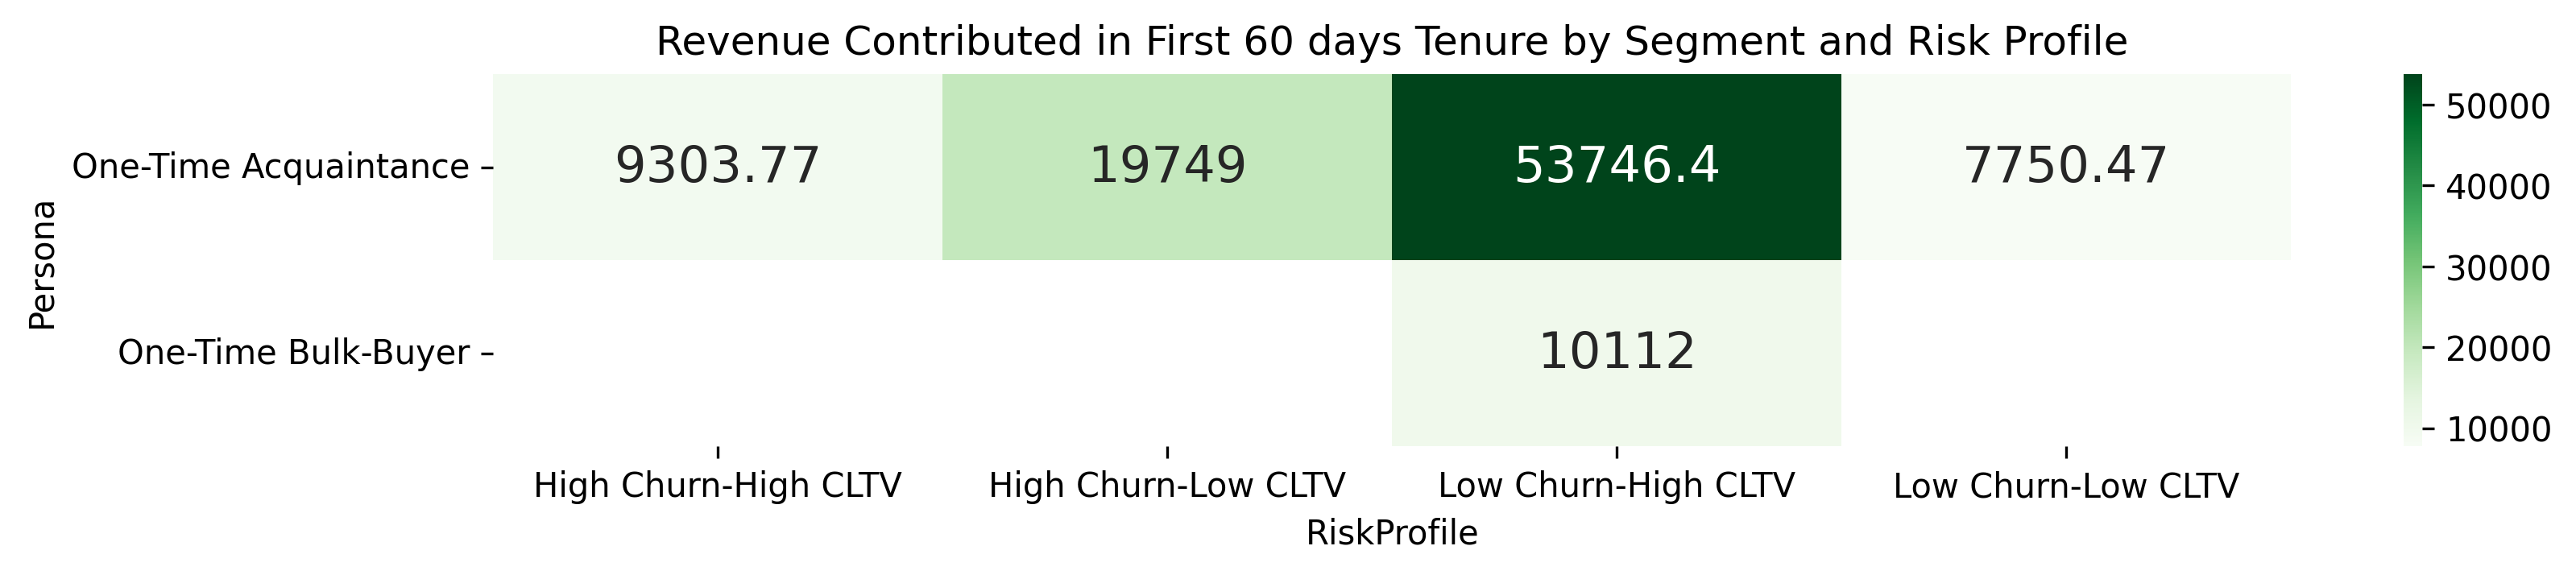

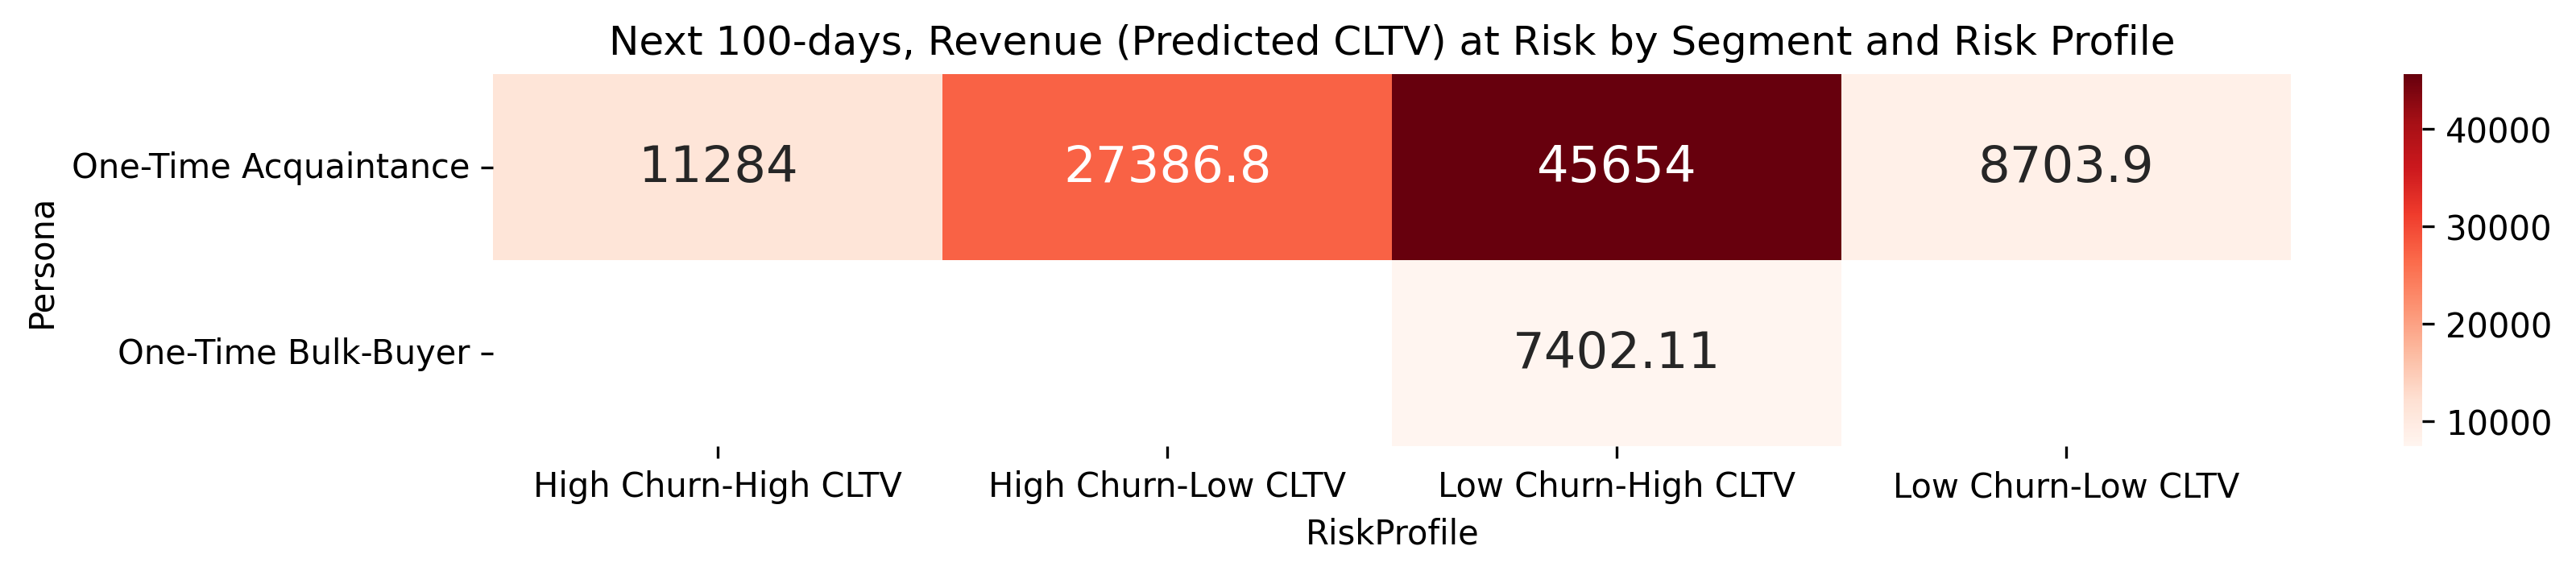

In [52]:
summary1 = df3.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'TotalRevenue', aggfunc = 'sum')

summary1

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary1, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Greens')
plt.title('Revenue Contributed in First 60 days Tenure by Segment and Risk Profile')
plt.show()

summary1 = churned_df.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'PredictedCLTV', aggfunc = 'sum')

summary1

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary1, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Reds')
plt.title('Next 100-days, Revenue (Predicted CLTV) at Risk by Segment and Risk Profile')
plt.show()
